In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
                                          # Load the Dataset

In [3]:
df = pd.read_csv("customer_churn.csv")

In [4]:
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
                                                       # Check Missing Values

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
                                                 # Check Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
                                    # Check Blank Values in TotalCharges

In [10]:
(df["TotalCharges"] == "").sum()

np.int64(0)

In [11]:
                                             # Replace Blank Values with NaN

In [12]:
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [13]:
                                            # Convert TotalCharges to Numeric

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [15]:
                           # Check Missing Values Again

In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
df.dropna(inplace=True)

In [18]:
       # Verify the Dataset
df.shape

(7032, 21)

In [19]:



                                                                       # Count the Churn Values

In [20]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [21]:
                                                         # Percentage of Churn

In [22]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

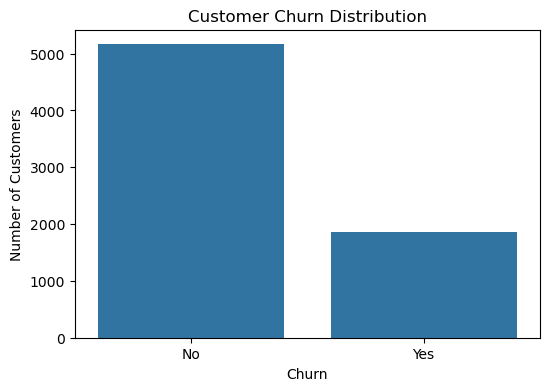

In [23]:

                                                                   # BAR CHART

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
                                                                   # Business Insight:

# Approximately 73% of customers are retained, while 27% have churned. Although the majority of customers stay with the company, the churn rate is 
# significant and should be analyzed further to identify the reasons behind customer loss.

In [25]:
                                                 # Step 2: Gender vs Churn

In [26]:
df.groupby("gender")["Churn"].value_counts()

gender  Churn
Female  No       2544
        Yes       939
Male    No       2619
        Yes       930
Name: count, dtype: int64

In [27]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


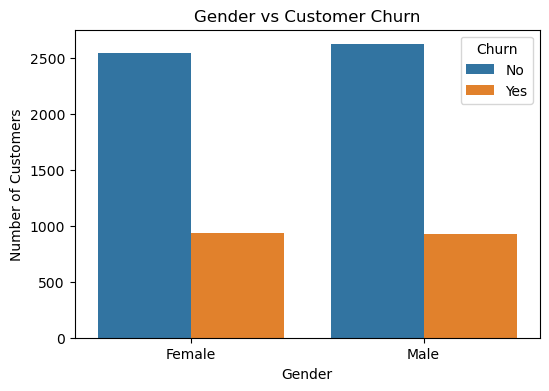

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [29]:
# Business Insight

# Male and female customers show a similar churn pattern. Gender does not appear to have a significant impact on customer churn. Therefore, 
# customer retention strategies should focus on other factors such as contract type, monthly charges, and tenure.

In [30]:
                                                                 # Step 3: Senior Citizen vs Churn

In [31]:
df.groupby("SeniorCitizen")["Churn"].value_counts()

SeniorCitizen  Churn
0              No       4497
               Yes      1393
1              No        666
               Yes       476
Name: count, dtype: int64

In [32]:
             # Create a Frequency Table
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


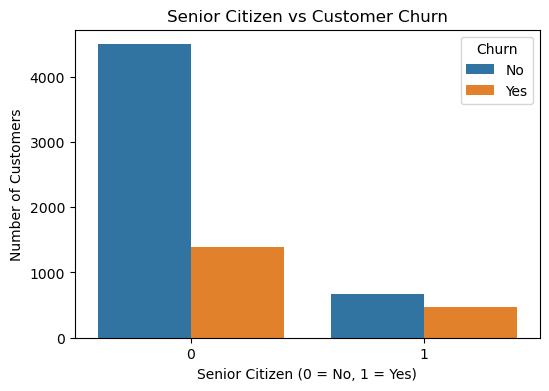

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
                                                      # Business Insight

# Senior citizens have a higher likelihood of churning compared to non-senior customers. The company should design special retention plans and 
# personalized support for senior customers to reduce churn.

In [35]:
                                                        #STEP 4  Contract Type vs Churn

In [36]:
df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
Name: count, dtype: int64

In [37]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


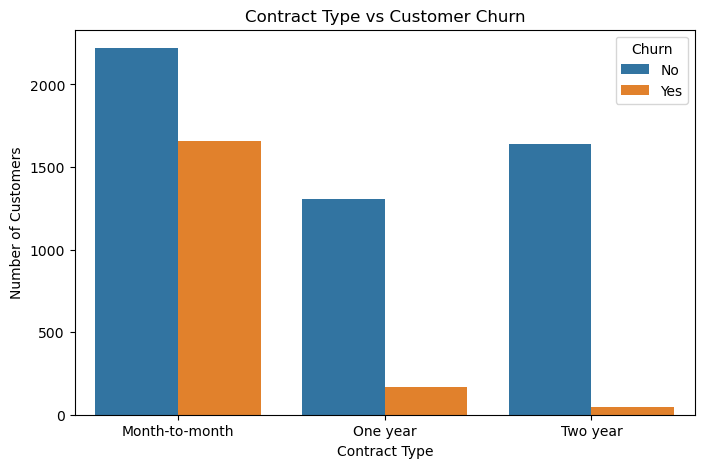

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [39]:
# Business Insight

# Customers with month-to-month contracts have the highest churn rate. Customers with one-year and two-year contracts are more likely to stay with 
# the company. The company should encourage customers to switch to long-term contracts by offering discounts and loyalty benefits to reduce churn.

In [40]:
                                                        # Step 5: Partner vs Churn

In [41]:
df.groupby("Partner")["Churn"].value_counts()

Partner  Churn
No       No       2439
         Yes      1200
Yes      No       2724
         Yes       669
Name: count, dtype: int64

In [42]:
pd.crosstab(df["Partner"], df["Churn"])

Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


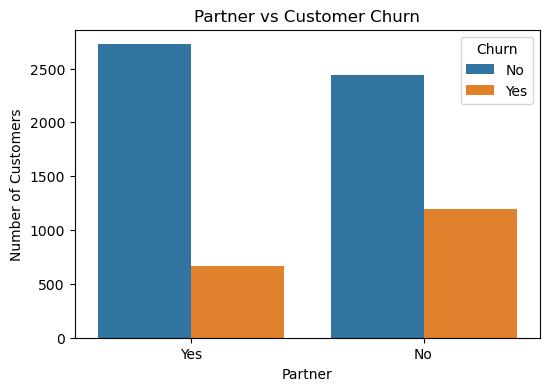

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(x="Partner", hue="Churn", data=df)

plt.title("Partner vs Customer Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

In [44]:
# Business Insight

# Customers without a partner show a higher churn rate.
# Customers with a partner are more likely to stay with the company.
# The company should focus retention strategies on customers who do not have a partner.

In [45]:
                                                           # Dependents vs Churn

In [46]:
df.groupby("Dependents")["Churn"].value_counts()

Dependents  Churn
No          No       3390
            Yes      1543
Yes         No       1773
            Yes       326
Name: count, dtype: int64

In [47]:
pd.crosstab(df["Dependents"], df["Churn"])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


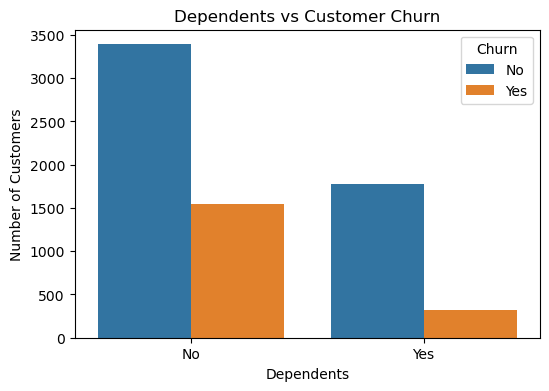

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(x="Dependents", hue="Churn", data=df)

plt.title("Dependents vs Customer Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

In [49]:

# Business Insight

# Customers without dependents have a higher churn rate compared to customers with dependents. Customers with dependents appear to be more loyal 
# and are more likely to continue using the company's services.

In [50]:
                                                                   # Internet Service vs Customer Churn

In [52]:
df.groupby("InternetService")["Churn"].value_counts()
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


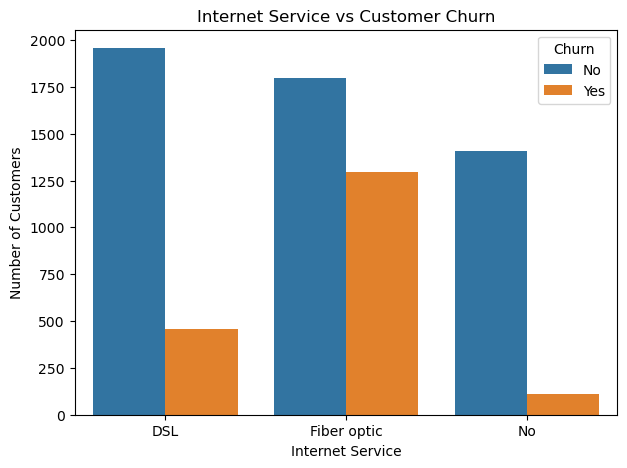

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Business Insight

# Customers using Fiber Optic internet service have the highest churn rate compared to DSL and customers with no internet service. The company 
# should investigate service quality, pricing, and customer satisfaction for Fiber Optic users.

In [ ]:
                                                            # Payment Method vs Customer Churn

In [54]:
df.groupby("PaymentMethod")["Churn"].value_counts()

PaymentMethod              Churn
Bank transfer (automatic)  No       1284
                           Yes       258
Credit card (automatic)    No       1289
                           Yes       232
Electronic check           No       1294
                           Yes      1071
Mailed check               No       1296
                           Yes       308
Name: count, dtype: int64

In [55]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


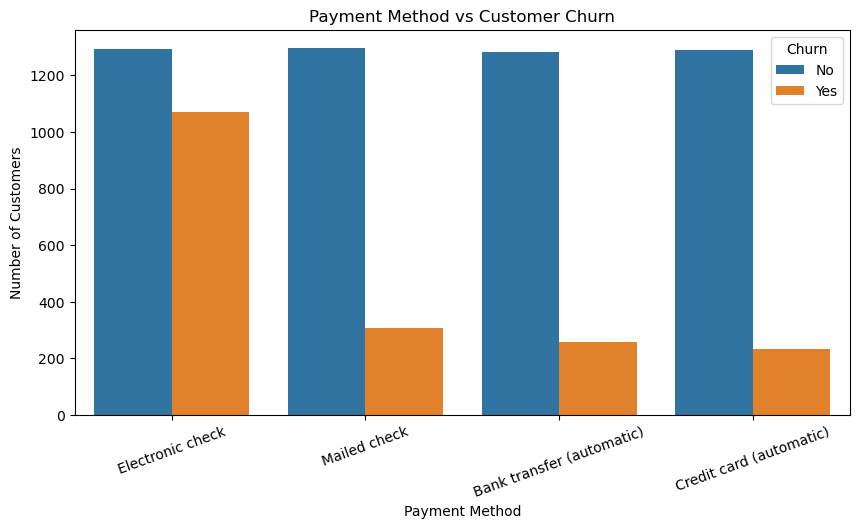

In [56]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Business Insight

# Customers using Electronic Check have the highest churn rate. The company should improve the payment experience and encourage customers to 
# switch to more reliable payment methods such as automatic bank transfer or credit card.

In [ ]:
                                          # Monthly Charges Distribution

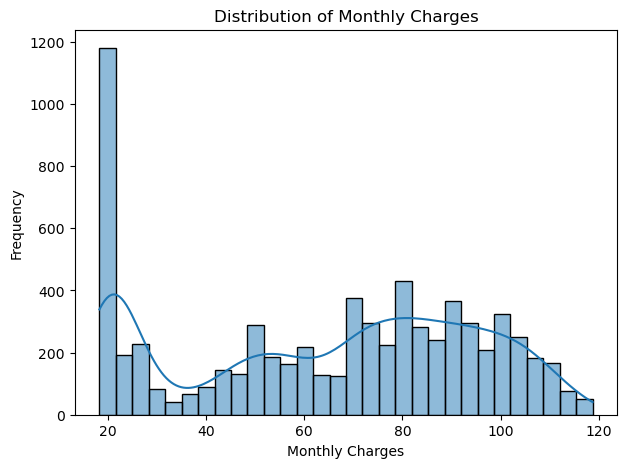

In [57]:
plt.figure(figsize=(7,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Business Insight

# Most customers have monthly charges between moderate and high values. The boxplot helps identify outliers, while the histogram shows the overall 
# distribution of monthly charges.